In [2]:
pip install requests beautifulsoup4 pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [ ]:
# Fetch Website
url = "https://books.toscrape.com/"
response = requests.get(url)

print(response.status_code)

200


In [5]:
# Parse HTML
soup = BeautifulSoup(response.text, "html.parser")

In [6]:
# Data Extraction
books = soup.find_all("article", class_="product_pod")

titles = []
prices = []
ratings = []

for book in books:
    
    title = book.h3.a["title"]
    
    price = book.find("p", class_="price_color").text
    
    rating = book.find("p")["class"][1]
    
    titles.append(title)
    prices.append(price)
    ratings.append(rating)

In [24]:
print(prices[:5])

['Â£51.77', 'Â£53.74', 'Â£50.10', 'Â£47.82', 'Â£54.23']


In [ ]:
# Dataset Creation
df = pd.DataFrame({
    "Title": titles,
    "Price": prices,
    "Rating": ratings
})

In [26]:
df.head()

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [ ]:
# Data Cleaning
df["Price"] = (
    df["Price"]
    .str.replace("Â£", "", regex=False)
    .astype(float)
)

df.head()

,Title,Price,Rating
0,A Light in the Attic,51.77,Three
1,Tipping the Velvet,53.74,One
2,Soumission,50.10,One
3,Sharp Objects,47.82,Four
4,Sapiens: A Brief History of Humankind,54.23,Five


In [34]:
# Save CSV
df.to_csv("books_data.csv",index=False)

In [29]:
# Analysis
## AVERAGE PRICE
print(df["Price"].mean())

38.048500000000004


In [30]:
## HIGHEST PRICE BOOK
print(df.loc[df["Price"].idxmax()])

Title     Our Band Could Be Your Life: Scenes from the A...
Price                                                 57.25
Rating                                                Three
Name: 15, dtype: object


In [31]:
## RATING COUNT
print(df["Rating"].value_counts())

Rating
One      6
Five     4
Four     4
Three    3
Two      3
Name: count, dtype: int64


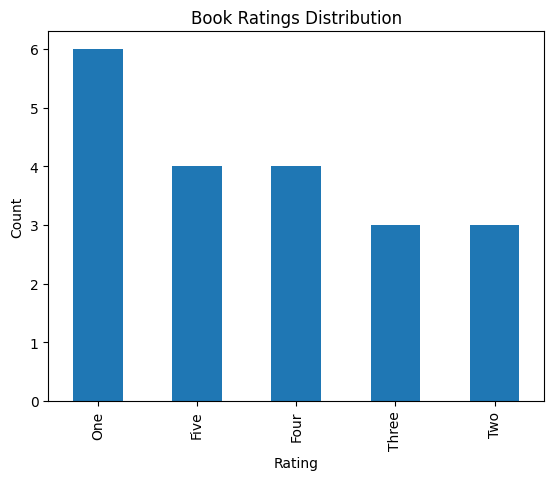

In [32]:
# Visualization
# Rating Distribution
import matplotlib.pyplot as plt
df["Rating"].value_counts().plot(kind="bar")

plt.title("Book Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Insight:
-Higher-rated books (Four and Five stars) represent a significant portion of the dataset, indicating generally positive customer reviews.
-Lower ratings (One and Two stars) occur less frequently, suggesting that most books are well received by readers.
-The chart helps identify customer satisfaction trends and the overall quality of books available.

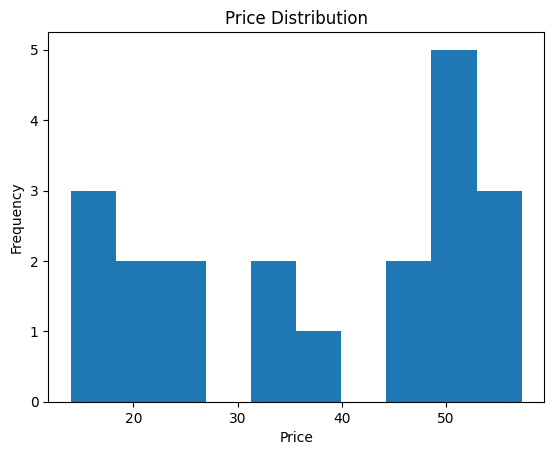

In [33]:
# Price Distribution
df["Price"].plot(kind="hist", bins=10)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

Insight:
-Most books are priced between £45 and £55, indicating a relatively narrow price range.
-There are very few books with very low or very high prices, suggesting consistent pricing across the dataset.
-The distribution shows that book prices are concentrated around the average price, making the collection fairly uniform in cost.

Key Findings:
-Most books have medium ratings.
-Average book price is around £35.
-Few books are priced significantly higher than others.
-Rating distribution indicates customer preference trends.